# 3 - ASK / QAM-IQ Demod (mit AWGN-Störung)

Dieses Notebook liest das in `1-ASK-basics.ipynb` erzeugte ASK-Signal aus
`recordings/ask.json` ein, addiert ein einstellbares **additives weisses
gaussverteiltes Rauschen (AWGN)** und demoduliert das Signal über einen
lokal erzeugten Cosinus/Sinus-Oszillator (I/Q-Downconversion).

Am Ende wird das Zeigerdiagramm $I$ vs. $Q$ (Konstellation) mit
Achsenverhältnis $1{:}1$ geplottet.

## Prinzip

1. **Lokaler Oszillator (LO)** mit Frequenz $f_{LO} \approx f_c$:
   - $\cos(2\pi f_{LO} t + \varphi_{LO})$ für den I-Zweig
   - $-\sin(2\pi f_{LO} t + \varphi_{LO})$ für den Q-Zweig

2. **Mischung (Downconversion)**
   - $I_{raw}(t) = s(t)\cos(2\pi f_{LO} t)$
   - $Q_{raw}(t) = -s(t)\sin(2\pi f_{LO} t)$

3. **Tiefpass auf I/Q** (didaktisch wieder Sliding-Averager).

4. **Magnitude** $u_{mag}(t) = \sqrt{I(t)^2 + Q(t)^2}$ und/oder direkte
   Bit-Entscheidung anhand des I-Kanals (bei $f_{LO} = f_c$ und
   $\varphi_{LO} = \varphi_c$ liegt die gesamte Energie in $I$, $Q \approx 0$).

Für ASK mit Modulator $s(t) = U_c (1 + m\,d(t))\cos(2\pi f_c t)$ ergibt der
matched Demodulator nach Tiefpass:

$$I(t) \approx \tfrac{U_c}{2}\bigl(1 + m\,d(t)\bigr), \qquad Q(t) \approx 0.$$

Die Konstellation enthält also zwei Cluster auf der I-Achse bei
$\tfrac{U_c}{2}(1 \pm m)$.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().resolve()))

try:
    from IPython import get_ipython
    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic("matplotlib", "widget")
except Exception:
    pass

import numpy as np
import matplotlib.pyplot as plt

from lib.plot_style import apply_lab_matplotlib_style

apply_lab_matplotlib_style()

USE_FFT_WINDOW = True
FFT_WINDOW_KIND = 'hann'   # 'hann' | 'hamming' | 'rect'


## ASK-Recording laden

Liest `recordings/ask.json` (siehe Notebook 1) und übernimmt alle
Modulator-Parameter aus den Metadaten.

In [2]:
from pathlib import Path

from lib.ask_recording import load_ask_recording_v1

rec_path = Path('recordings/ask.json')
rec = load_ask_recording_v1(rec_path)

fs = rec.fs_hz
f_c = rec.f_carrier_hz
phi_c = rec.phi_carrier_rad
U_c = rec.U_c
m = rec.modulation_index
samples_per_bit = rec.samples_per_bit
R_b = rec.bit_rate_hz
T_b = 1.0 / R_b
n_bits = rec.n_bits
N_sig = rec.n_samples

s_clean = np.asarray(rec.samples, dtype=np.float64)
bits_orig = np.asarray(rec.bits, dtype=np.int8)

t = np.arange(N_sig) / fs

print(f'Geladen: {rec_path} ({N_sig} Samples)')
print(f'  fs = {fs} Hz, f_c = {f_c} Hz, phi_c = {phi_c:.3f} rad, U_c = {U_c}')
print(f'  m = {m}, samples_per_bit = {samples_per_bit}, R_b = {R_b:.1f} bit/s, n_bits = {n_bits}')

Geladen: recordings\ask.json (18000 Samples)
  fs = 200000.0 Hz, f_c = 20000.0 Hz, phi_c = 0.000 rad, U_c = 1.0
  m = 0.7, samples_per_bit = 100, R_b = 2000.0 bit/s, n_bits = 180


## AWGN-Störung addieren

Wir simulieren einen rauschbehafteten Empfangspfad durch Addition von
**Additive White Gaussian Noise (AWGN)**:

$$r(t) = s(t) + n(t), \qquad n(t) \sim \mathcal N(0, \sigma_n^2)$$

### SNR-Bezug: gesamte Abtastbandbreite vs. Signaleffektivbandbreite

Wenn wir pro Abtastwert Rauschen mit Varianz $\sigma_n^2$ addieren, ist das
**weisse Rauschen** im digitalen Modell nahezu **gleichmäßig** über die
Nyquist-Bandbreite $f_s/2$ verteilt.

Die **Information** des ASK-Signals ist jedoch typischerweise in einer viel
**schmaleren** effektiven Bandbreite konzentriert — in diesem Notebook nehmen
wir für eine **grobe** Labor-Näherung die **Bitrate** $R_b$ als
Referenzbandbreite (gleiche Größenordnung wie die Nutzbandbreite des
Basisband-Hüllkurvensignals).

Für weisses Rauschen gilt dann in sehr vereinfachter Form: Die Rauschleistung,
die in eine Bandbreite $R_b$ "hineinfällt", ist etwa proportional zu
$R_b/f_s$ der **gesamten** Rauschleistung pro Abtastwert.

Wenn der Student ein **Ziel-SNR** $\mathrm{SNR}_{\mathrm{bit}}$ (in dB) **innerhalb**
dieser Referenzbandbreite $R_b$ vorgibt, muss die Varianz der Abtastwerte
**größer** gewählt werden als bei der naiven Formel, die implizit die
**gesamte** Nyquist-Bandbreite $f_s$ als Bezug nimmt.

**Korrektur (dB):**

$$\mathrm{SNR}_{\sigma,\mathrm{dB}} = \mathrm{SNR}_{\mathrm{bit,dB}} - 10\log_{10}\!\left(\frac{f_s}{R_b}\right)$$

Das ist **dieselbe** Korrektur wie

$$\mathrm{SNR}_{\sigma,\mathrm{dB}} = \mathrm{SNR}_{\mathrm{bit,dB}} + 10\log_{10}\!\left(\frac{R_b}{f_s}\right),$$

denn $10\log_{10}(R_b/f_s) = -10\log_{10}(f_s/R_b)$ (negativ, solange $R_b<f_s$).

**Setzen der Rauschvarianz (konsistent zur obigen Korrektur):**

$$\sigma_n^2 = P_s \cdot 10^{-\mathrm{SNR}_{\sigma,\mathrm{dB}}/10}
= P_s \cdot 10^{-\mathrm{SNR}_{\mathrm{bit,dB}}/10}\cdot \frac{f_s}{R_b}.$$

Konfigurierbar:
- `snr_db` ... gewünschtes SNR **bezogen auf effektive Bandbreite ~ $R_b$** [dB]
- `noise_seed` ... reproduzierbarer Zufall (`None` für echten Zufall)

Hinweis: Die Zeile "SNR (gemessen aus n[t])" misst weiterhin
$P_s/\mathrm{Var}(n)$ im **Zeitdiskreten** (pro Sample). Das entspricht
$\mathrm{SNR}_{\sigma,\mathrm{dB}}$ und ist **nicht** identisch mit
$\mathrm{SNR}_{\mathrm{bit,dB}}$ — das ist erwartbar und gerade der Punkt
dieser Korrektur.


In [3]:
snr_db = 15.0          # gewuenschtes SNR [dB], bezogen auf effektive Bandbreite ~ R_b (siehe Markdown)
noise_seed = 12345     # int oder None

rng = np.random.default_rng(noise_seed)
P_signal = float(np.mean(s_clean ** 2))

# Bandbreiten-Naeherung: weisses Rauschen ueber fs, Nutzinformation ~ R_b
snr_bandwidth_correction_db = 10.0 * np.log10(fs / max(R_b, 1e-12))
snr_db_sample = float(snr_db - snr_bandwidth_correction_db)

P_noise = P_signal * (10.0 ** (-snr_db_sample / 10.0))
sigma_n = float(np.sqrt(P_noise))
noise = rng.normal(loc=0.0, scale=sigma_n, size=N_sig)

s = s_clean + noise

P_noise_meas = float(np.mean(noise ** 2))
snr_db_meas = 10.0 * np.log10(P_signal / max(1e-30, P_noise_meas))
print(f"SNR (Ziel, ~R_b) = {snr_db:.2f} dB")
print(
    f"Bandbreitenkorrektur: 10*log10(fs/R_b) = {snr_bandwidth_correction_db:.2f} dB  "
    f"(SNR fuer sigma = {snr_db_sample:.2f} dB)"
)
print(f"P_signal = {P_signal:.4e}, sigma_n = {sigma_n:.4e}, P_noise = {P_noise:.4e}")
print(f"SNR (gemessen aus n[t], pro Sample) = {snr_db_meas:.2f} dB")


SNR (Ziel, ~R_b) = 15.00 dB
Bandbreitenkorrektur: 10*log10(fs/R_b) = 20.00 dB  (SNR fuer sigma = -5.00 dB)
P_signal = 6.7500e-01, sigma_n = 1.4610e+00, P_noise = 2.1345e+00
SNR (gemessen aus n[t], pro Sample) = -5.02 dB


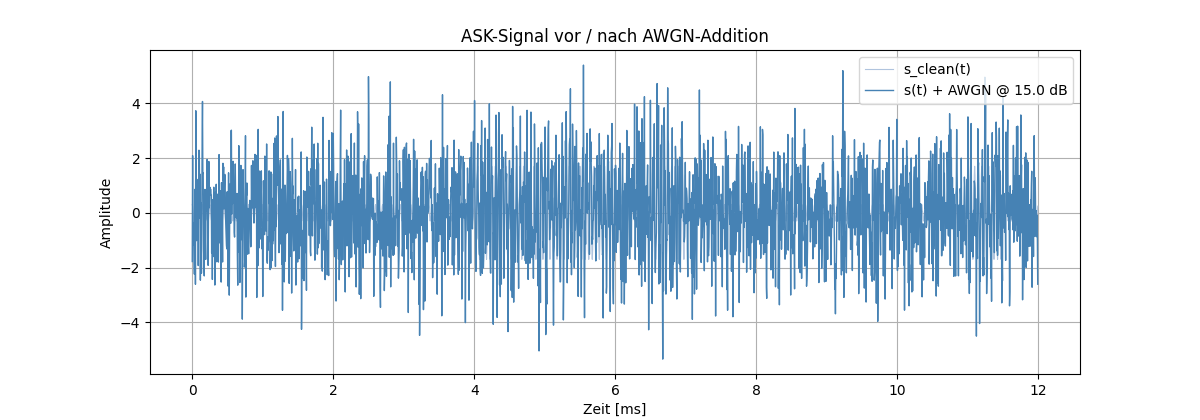

In [4]:
t_plot_ms = 12.0
n_plot = min(N_sig, int(t_plot_ms * 1e-3 * fs))

fig, ax = plt.subplots(figsize=(12, 4.2))
ax.plot(t[:n_plot] * 1e3, s_clean[:n_plot], lw=0.8, color='lightsteelblue', label='s_clean(t)')
ax.plot(t[:n_plot] * 1e3, s[:n_plot], lw=1.0, color='steelblue', label=f's(t) + AWGN @ {snr_db:.1f} dB')
ax.set_title('ASK-Signal vor / nach AWGN-Addition')
ax.set_xlabel('Zeit [ms]')
ax.set_ylabel('Amplitude')
ax.legend(loc='upper right')
plt.show()

### Spektrum des verrauschten Trägers

Im Vergleich zum sauberen ASK-Spektrum (Sidelobes $\pm k\,R_b$ um $f_c$) hebt
das AWGN-Plateau gleichmäßig den gesamten Frequenzbereich an.

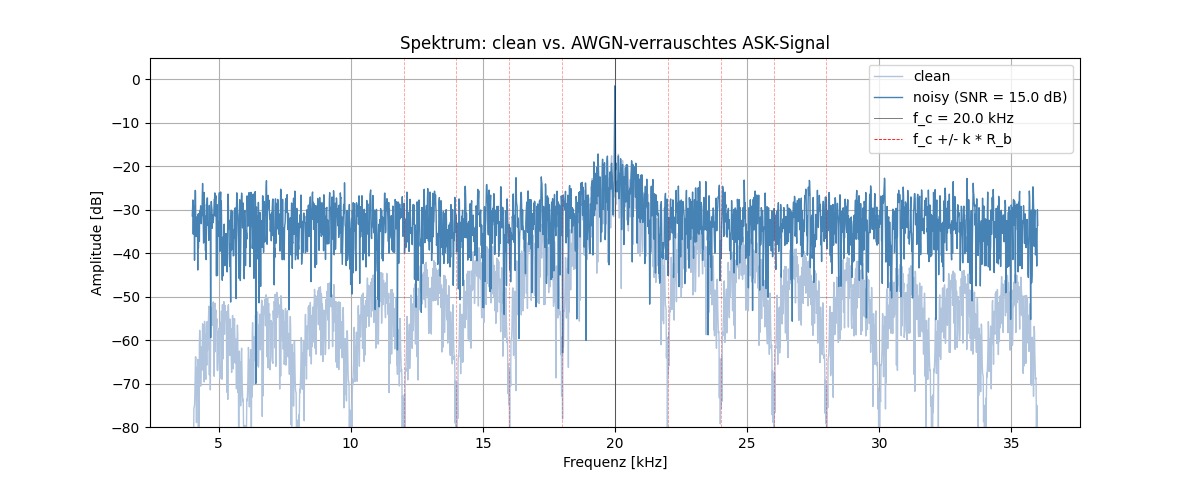

In [5]:
N_fft = 16384

def amp_spectrum(x, N_fft, fs, win=USE_FFT_WINDOW, kind=FFT_WINDOW_KIND):
    y = np.zeros(N_fft)
    n_copy = min(len(x), N_fft)
    y[:n_copy] = x[:n_copy]
    if win:
        if kind == 'hann':
            w = np.hanning(N_fft)
        elif kind == 'hamming':
            w = np.hamming(N_fft)
        else:
            w = np.ones(N_fft)
    else:
        w = np.ones(N_fft)
    cg = max(np.mean(w), 1e-12)
    X = np.fft.fft(y * w, n=N_fft)
    f = np.fft.fftfreq(N_fft, d=1.0 / fs)
    pos = f >= 0
    A = (2.0 / (N_fft * cg)) * np.abs(X[pos])
    return f[pos], A

f_pos, A_clean = amp_spectrum(s_clean, N_fft, fs)
_,     A_noisy = amp_spectrum(s,       N_fft, fs)

show = (f_pos >= max(0.0, f_c - 8 * R_b)) & (f_pos <= f_c + 8 * R_b)

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.plot(f_pos[show] / 1e3, 20 * np.log10(A_clean[show] + 1e-12), lw=1.0,
        color='lightsteelblue', label='clean')
ax.plot(f_pos[show] / 1e3, 20 * np.log10(A_noisy[show] + 1e-12), lw=1.0,
        color='steelblue', label=f'noisy (SNR = {snr_db:.1f} dB)')
ax.axvline(f_c / 1e3, color='black', ls='-', lw=0.6, alpha=0.6,
           label=f'f_c = {f_c/1e3:.1f} kHz')
for k in range(1, 5):
    for sgn in (-1, +1):
        ax.axvline((f_c + sgn * k * R_b) / 1e3,
                   color='red', ls='--', lw=0.6, alpha=0.4)
ax.plot([], [], 'r--', lw=0.6, label='f_c +/- k * R_b')
ax.set_title('Spektrum: clean vs. AWGN-verrauschtes ASK-Signal')
ax.set_xlabel('Frequenz [kHz]')
ax.set_ylabel('Amplitude [dB]')
ax.set_ylim(-80, 5)
ax.legend(loc='upper right')
plt.show()

## I/Q-Downconversion

Lokaler Oszillator nahe der Trägerfrequenz; bei perfekter Schätzung gilt
$f_{LO} = f_c$ und $\varphi_{LO} = \varphi_c$. Eine kleine Abweichung
$\Delta f = f_c - f_{LO}$ erzeugt eine langsame Rotation der Konstellation
(sichtbar im Zeigerdiagramm).

In [6]:
f_lo = f_c              # einstellbar; z. B. f_c + 50.0 fuer kleine Drift
phi_lo_deg = 0.0        # einstellbar; bewirkt nur eine I/Q-Drehung
phi_lo = np.deg2rad(phi_lo_deg) + phi_c

lo_i = np.cos(2 * np.pi * f_lo * t + phi_lo)
lo_q = -np.sin(2 * np.pi * f_lo * t + phi_lo)

I_raw = s * lo_i
Q_raw = s * lo_q

# Tiefpass: oberhalb der Bitrate, deutlich unter 2*f_c (Spiegelfrequenz nach Mischung)
f_lp = 2.0 * R_b
N_win = max(3, int(round(fs / max(1.0, f_lp))))
if N_win % 2 == 0:
    N_win += 1
h_lp = np.ones(N_win, dtype=np.float64) / N_win

I = np.convolve(I_raw, h_lp, mode='same')
Q = np.convolve(Q_raw, h_lp, mode='same')

u_mag = np.sqrt(I ** 2 + Q ** 2)

print(f'f_lo = {f_lo:.1f} Hz, |f_c - f_lo| = {abs(f_c - f_lo):.1f} Hz, N_win = {N_win}')
print(f'I/Q-Skala (erwartet, ohne Rauschen): U_c/2 = {U_c/2:.3f},')
print(f'  Cluster bei I = U_c/2 * (1-m) = {U_c/2*(1-m):.3f}  und  U_c/2 * (1+m) = {U_c/2*(1+m):.3f}')

f_lo = 20000.0 Hz, |f_c - f_lo| = 0.0 Hz, N_win = 51
I/Q-Skala (erwartet, ohne Rauschen): U_c/2 = 0.500,
  Cluster bei I = U_c/2 * (1-m) = 0.150  und  U_c/2 * (1+m) = 0.850


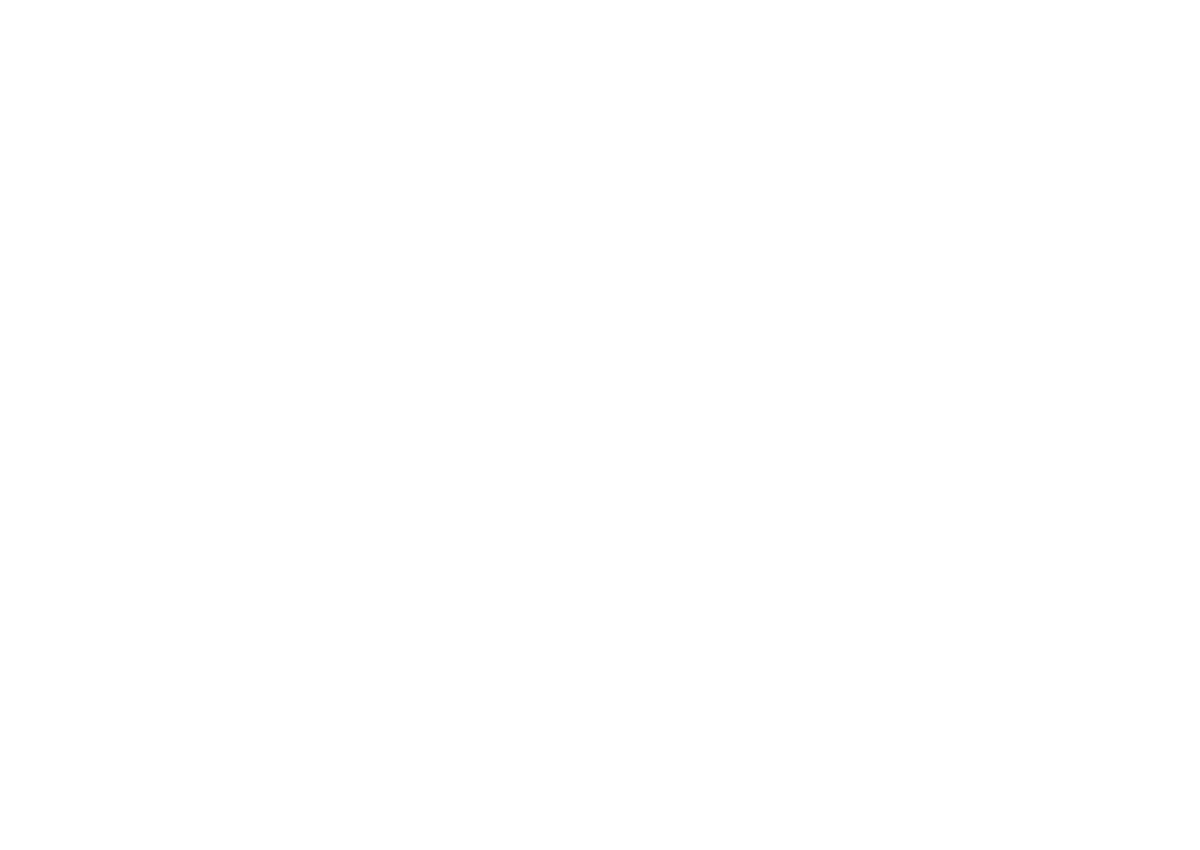

In [7]:
fig, ax = plt.subplots(4, 1, figsize=(12, 8.5), sharex=True)
ax[0].plot(t[:n_plot] * 1e3, s[:n_plot], lw=1.0, color='steelblue')
ax[0].set_title(f'Eingangssignal s(t) (verrauscht, SNR = {snr_db:.1f} dB)')
ax[0].set_ylabel('s(t)')

ax[1].plot(t[:n_plot] * 1e3, I[:n_plot], lw=1.2, color='C0')
ax[1].axhline(U_c / 2 * (1 - m), color='red', ls='--', lw=0.7, alpha=0.6)
ax[1].axhline(U_c / 2 * (1 + m), color='green', ls='--', lw=0.7, alpha=0.6)
ax[1].set_title('I-Kanal (nach LP)')
ax[1].set_ylabel('I')

ax[2].plot(t[:n_plot] * 1e3, Q[:n_plot], lw=1.2, color='C3')
ax[2].set_title('Q-Kanal (nach LP)')
ax[2].set_ylabel('Q')

ax[3].plot(t[:n_plot] * 1e3, u_mag[:n_plot], lw=1.4, color='C2')
ax[3].set_title('Magnitude sqrt(I^2 + Q^2)')
ax[3].set_ylabel('|.|')
ax[3].set_xlabel('Zeit [ms]')

plt.tight_layout()
plt.show()

### Spektrum nach Mischung (I_raw)

Die Mischung erzeugt zwei Replika: eine im Basisband um $0$ Hz und eine
Spiegelkomponente um $\pm 2 f_c$. Der nachfolgende Tiefpass entfernt die obere
Komponente.

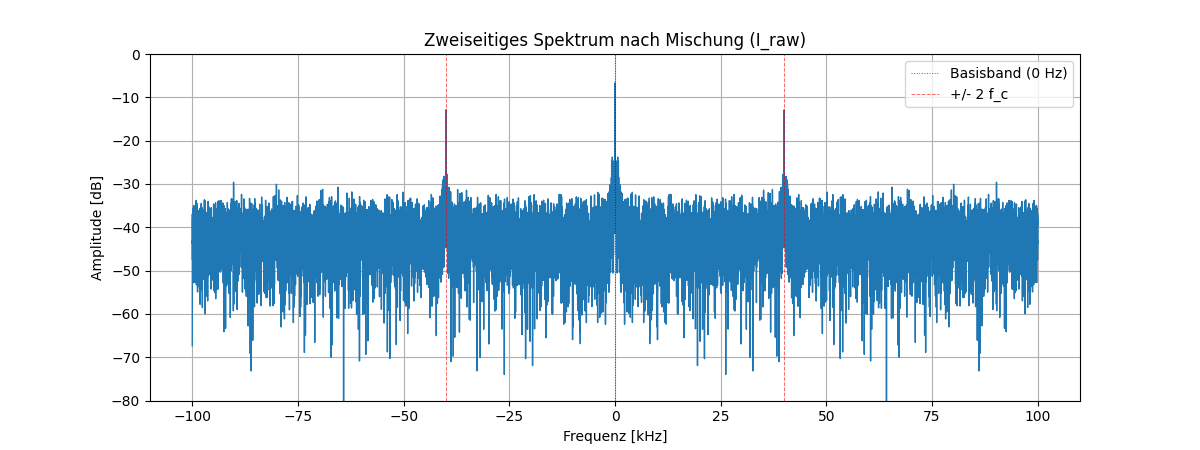

In [8]:
y = np.zeros(N_fft)
n_copy = min(len(I_raw), N_fft)
y[:n_copy] = I_raw[:n_copy]
if USE_FFT_WINDOW:
    w = np.hanning(N_fft) if FFT_WINDOW_KIND == 'hann' else (
        np.hamming(N_fft) if FFT_WINDOW_KIND == 'hamming' else np.ones(N_fft))
else:
    w = np.ones(N_fft)
cg = max(np.mean(w), 1e-12)
X = np.fft.fftshift(np.fft.fft(y * w, n=N_fft))
f_two = np.fft.fftshift(np.fft.fftfreq(N_fft, d=1.0 / fs))
A = np.abs(X) / (N_fft * cg)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(f_two / 1e3, 20 * np.log10(A + 1e-12), lw=1.0)
ax.axvline(0.0, color='black', ls=':', lw=0.7, alpha=0.6, label='Basisband (0 Hz)')
ax.axvline(2 * f_c / 1e3, color='red', ls='--', lw=0.7, alpha=0.6, label=f'+/- 2 f_c')
ax.axvline(-2 * f_c / 1e3, color='red', ls='--', lw=0.7, alpha=0.6)
ax.set_title('Zweiseitiges Spektrum nach Mischung (I_raw)')
ax.set_xlabel('Frequenz [kHz]')
ax.set_ylabel('Amplitude [dB]')
ax.set_ylim(-80, 0)
ax.legend(loc='upper right')
plt.show()

## Zeigerdiagramm (I vs. Q) - Konstellation

Wir tasten $I$ und $Q$ in der Mitte jedes Bitintervalls ab und tragen sie als
Punkte in der komplexen Ebene auf. Das Achsenverhältnis ist auf $1{:}1$
gesetzt, damit Distanzen geometrisch korrekt erscheinen.

Bei matched LO ($f_{LO} = f_c$, $\varphi_{LO} = \varphi_c$) ergeben sich zwei
Cluster auf der I-Achse:

$$\big(I, Q\big) \approx \Big(\tfrac{U_c}{2}(1 - m),\ 0\Big)\ \text{und}\ \Big(\tfrac{U_c}{2}(1 + m),\ 0\Big)$$

Das AWGN streut beide Cluster radial - bei kleinerem SNR überlappen sie.

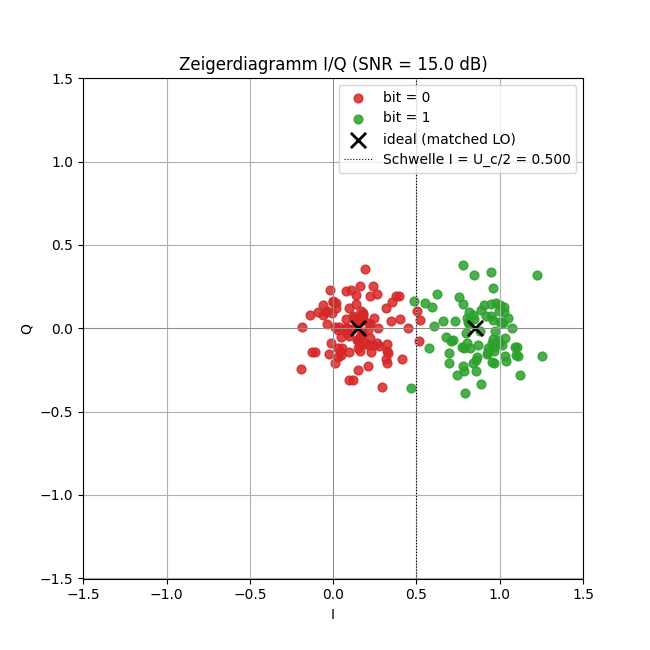

In [9]:
sample_idx = (np.arange(n_bits) * samples_per_bit + samples_per_bit // 2)
sample_idx = np.clip(sample_idx, 0, N_sig - 1)

I_sym = I[sample_idx]
Q_sym = Q[sample_idx]

I_dense = I_sym[bits_orig == 1]
I_sparse = I_sym[bits_orig == 0]
Q_dense = Q_sym[bits_orig == 1]
Q_sparse = Q_sym[bits_orig == 0]

# Ideale Cluster-Mittelpunkte (matched LO)
I_hi = U_c / 2.0 * (1 + m)
I_lo = U_c / 2.0 * (1 - m)
I_thr = U_c / 2.0

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(I_sparse, Q_sparse, s=40, color='C3', alpha=0.85, label='bit = 0')
ax.scatter(I_dense, Q_dense, s=40, color='C2', alpha=0.85, label='bit = 1')
ax.scatter([I_lo, I_hi], [0.0, 0.0], marker='x', s=120, color='black',
           lw=2.0, label='ideal (matched LO)')
ax.axvline(I_thr, color='black', ls=':', lw=0.8, label=f'Schwelle I = U_c/2 = {I_thr:.3f}')
ax.axhline(0.0, color='gray', lw=0.5)
ax.axvline(0.0, color='gray', lw=0.5)
lim = max(abs(I_hi), abs(I_lo), float(np.max(np.abs(I_sym))), float(np.max(np.abs(Q_sym)))) * 1.2 + 1e-3
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_aspect('equal', adjustable='box')
ax.set_title(f'Zeigerdiagramm I/Q (SNR = {snr_db:.1f} dB)')
ax.set_xlabel('I')
ax.set_ylabel('Q')
ax.legend(loc='upper right')
plt.show()

## Bitentscheidung und BER

Schwellenentscheidung auf dem I-Kanal: $\hat b_k = 1$ falls
$I[k\,T_b + T_b/2] > U_c/2$, sonst $\hat b_k = 0$. Vergleich mit den im
JSON gespeicherten Originalbits ergibt die Bitfehlerrate.

In [10]:
bits_demod = (I_sym > I_thr).astype(np.int8)
n_err = int(np.sum(bits_demod != bits_orig))
ber = n_err / max(1, n_bits)
print(f'Bitfehler: {n_err} / {n_bits}  ->  BER = {ber:.3e}  (SNR = {snr_db:.1f} dB)')
if n_err == 0:
    print('Alle Bits korrekt rekonstruiert.')

Bitfehler: 5 / 180  ->  BER = 2.778e-02  (SNR = 15.0 dB)


## Referenz: theoretische BER-Kurve (unkodiertes BPSK)

Für **unkodiertes, kohärentes BPSK** mit matched Filter und AWGN gilt
näherungsweise (Standardformel mit $E_b/N_0$):

$$P_b = Q\!\left(\sqrt{2\,\frac{E_b}{N_0}}\right),$$

wobei $Q(x)=\int_x^\infty \frac{1}{\sqrt{2\pi}}e^{-t^2/2}\,dt$.

**Didaktik-Hinweis:** Das ist eine **Referenzkurve** für BPSK. ASK/OOK ist
verwandt, aber je nach Demodulation/Schwelle **nicht** 1:1 identisch — für
exakte ASK-BER bräuchte man das passende Detektionsmodell. Trotzdem ist die
BPSK-Kurve gut geeignet, um **Größenordnungen** zu verstehen und um
$E_b/N_0$-Werte zu einer **Ziel-BER** rückzurechnen (Aufgabenstellung).

Der Slider setzt die Marker auf **allen vier** Kurven (gleiches $E_b/N_0$) und zeigt die zugehörigen BER-Werte.
**Interaktiver Slider:** Ohne interaktives Matplotlib-Backend sind
`matplotlib.widgets.Slider` in Jupyter oft **nicht mit der Maus bedienbar**
(klassisches `inline` liefert nur statische PNGs). In der **Import-Zelle**
wird deshalb wie in `4-ASK-SDR-demod-iq.ipynb` `%matplotlib widget` gesetzt
(Paket `ipympl` installieren). Nach Wechsel des Backends ggf. **Kernel neu
starten** und das Notebook von oben ausführen.

**$E_b/N_0$-Bereich:** Plot und Slider sind auf **$-1{,}6$ dB bis $+15$ dB**
begrenzt. Unterhalb der Shannon-Größenordnung (ca. $-1{,}59$ dB für
$R=1$ bit/s/Hz auf dem AWGN-Kanal) ist **zuverlässige** Übertragung ohne
Kodierung streng genommen nicht möglich; die vertikale Linie markiert die
untere Plotgrenze didaktisch.


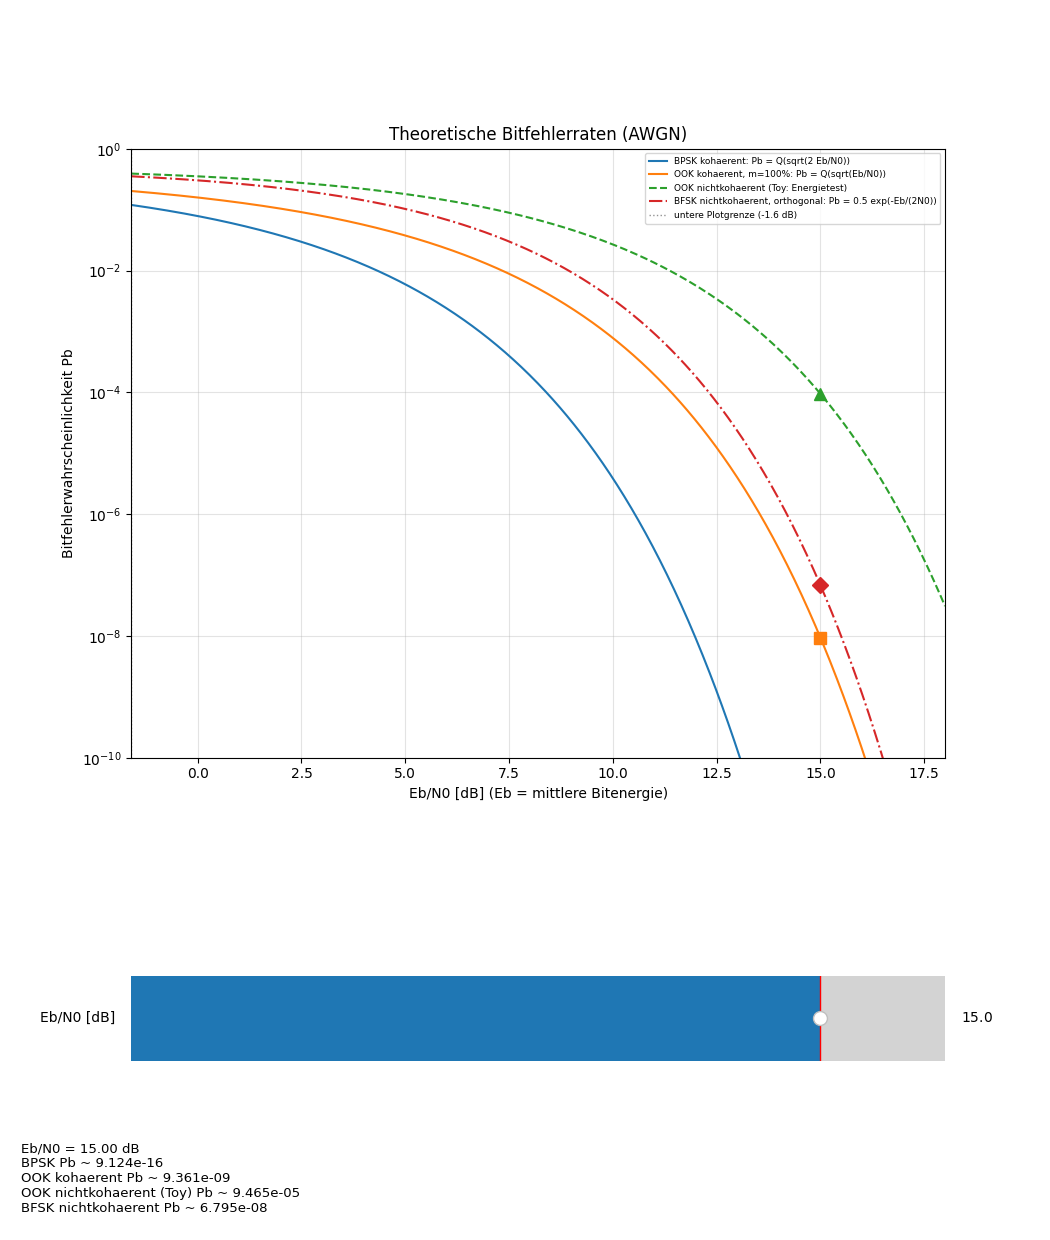

In [11]:
from scipy.stats import norm, chi2, ncx2
from matplotlib.widgets import Slider

EBN0_MIN_DB = -1.6
EBN0_MAX_DB = 18.0

snr_axis_db = np.linspace(EBN0_MIN_DB, EBN0_MAX_DB, 800)
gamma = 10.0 ** (snr_axis_db / 10.0)

# BPSK (kohaerent): Pb = Q(sqrt(2 Eb/N0))
pb_bpsk = norm.sf(np.sqrt(2.0 * gamma))

# Kohaerentes binaeres OOK (100%): Eb = mittlere Bitenergie -> Pb = Q(sqrt(Eb/N0))
pb_ook = norm.sf(np.sqrt(gamma))

# --- Nichtkohaerentes OOK (didaktisches Toy-Modell, feste Parameter) ---
N0_REF = 1.0
T_GRID = np.linspace(0.05, 45.0, 420)
nc = 2.0 * gamma
pfa = 1.0 - chi2.cdf(T_GRID, df=2)
pmiss = ncx2.cdf(T_GRID[None, :], df=2, nc=nc[:, None])
pb_ncook = 0.5 * np.min(pfa[None, :] + pmiss, axis=1)

# --- Nichtkohaerente orthogonale BFSK (2 Frequenzen, gleiche Eb, Envelope-/Quadrat-Vergleich) ---
# Geschlossene BER-Formel (z.B. Proakis / Sklar): Pb = 0.5 * exp(-Eb / (2 N0))
# Voraussetzung: orthogonale Signale, gleiche a-priori-Wahrscheinlichkeit.
pb_ncfsk = 0.5 * np.exp(-0.5 * gamma)

pb_bpsk = np.clip(pb_bpsk, 1e-14, 1.0)
pb_ook = np.clip(pb_ook, 1e-14, 1.0)
pb_ncook = np.clip(pb_ncook, 1e-14, 1.0)
pb_ncfsk = np.clip(pb_ncfsk, 1e-14, 1.0)


def _pb_nc_at_gamma(g_lin: float) -> float:
    nc1 = 2.0 * float(g_lin)
    pfa1 = 1.0 - chi2.cdf(T_GRID, df=2)
    pm1 = ncx2.cdf(T_GRID, df=2, nc=nc1)
    return float(0.5 * np.min(pfa1 + pm1))


def _pb_ncfsk_at_gamma(g_lin: float) -> float:
    return float(0.5 * np.exp(-0.5 * float(g_lin)))


marker_x = float(np.clip(float(globals().get("snr_db", 8.0)), EBN0_MIN_DB, EBN0_MAX_DB))
g_m = 10.0 ** (marker_x / 10.0)
marker_pb_bpsk = float(norm.sf(np.sqrt(2.0 * g_m)))
marker_pb_ook = float(norm.sf(np.sqrt(g_m)))
marker_pb_nc = _pb_nc_at_gamma(g_m)
marker_pb_fsk = _pb_ncfsk_at_gamma(g_m)

fig = plt.figure(figsize=(10.5, 12.4))
gs = fig.add_gridspec(2, 1, height_ratios=[1.0, 0.28], hspace=0.45)
ax = fig.add_subplot(gs[0, 0])
ax_slider = fig.add_subplot(gs[1, 0])

ax.semilogy(snr_axis_db, pb_bpsk, lw=1.5, color="C0", label="BPSK kohaerent: Pb = Q(sqrt(2 Eb/N0))")
ax.semilogy(snr_axis_db, pb_ook, lw=1.5, color="C1", label="OOK kohaerent, m=100%: Pb = Q(sqrt(Eb/N0))")
ax.semilogy(
    snr_axis_db,
    pb_ncook,
    lw=1.5,
    ls="--",
    color="C2",
    label="OOK nichtkohaerent (Toy: Energietest)",
)
ax.semilogy(
    snr_axis_db,
    pb_ncfsk,
    lw=1.5,
    ls="-.",
    color="C3",
    label="BFSK nichtkohaerent, orthogonal: Pb = 0.5 exp(-Eb/(2N0))",
)
ax.axvline(EBN0_MIN_DB, color="gray", ls=":", lw=1.0, alpha=0.85, label="untere Plotgrenze (-1.6 dB)")
ax.set_xlim(EBN0_MIN_DB, EBN0_MAX_DB)
ax.set_title("Theoretische Bitfehlerraten (AWGN)")
ax.set_xlabel("Eb/N0 [dB] (Eb = mittlere Bitenergie)")
ax.set_ylabel("Bitfehlerwahrscheinlichkeit Pb")
ax.grid(True, which="both", alpha=0.35)
ax.set_ylim(1e-10, 1.0)

(m_bpsk,) = ax.plot([marker_x], [marker_pb_bpsk], "o", color="C0", ms=8, zorder=6)
(m_ook,) = ax.plot([marker_x], [marker_pb_ook], "s", color="C1", ms=8, zorder=6)
(m_nc,) = ax.plot([marker_x], [marker_pb_nc], "^", color="C2", ms=8, zorder=6)
(m_fsk,) = ax.plot([marker_x], [marker_pb_fsk], "D", color="C3", ms=8, zorder=6)
info_text = fig.text(0.02, 0.02, "", fontsize=9.5, ha="left", va="bottom")


def _fmt_pb(p: float) -> str:
    if p >= 1e-3:
        return f"{p:.4e}"
    return f"{p:.3e}"


def update_marker(snr_sel_db):
    snr_sel_db = float(np.clip(float(snr_sel_db), EBN0_MIN_DB, EBN0_MAX_DB))
    g = 10.0 ** (snr_sel_db / 10.0)
    pb_b = float(norm.sf(np.sqrt(2.0 * g)))
    pb_o = float(norm.sf(np.sqrt(g)))
    pb_n = _pb_nc_at_gamma(g)
    pb_f = _pb_ncfsk_at_gamma(g)
    m_bpsk.set_data([snr_sel_db], [pb_b])
    m_ook.set_data([snr_sel_db], [pb_o])
    m_nc.set_data([snr_sel_db], [pb_n])
    m_fsk.set_data([snr_sel_db], [pb_f])
    info_text.set_text(
        f"Eb/N0 = {snr_sel_db:.2f} dB\n"
        f"BPSK Pb ~ {_fmt_pb(pb_b)}\n"
        f"OOK kohaerent Pb ~ {_fmt_pb(pb_o)}\n"
        f"OOK nichtkohaerent (Toy) Pb ~ {_fmt_pb(pb_n)}\n"
        f"BFSK nichtkohaerent Pb ~ {_fmt_pb(pb_f)}"
    )
    fig.canvas.draw_idle()


slider = Slider(
    ax=ax_slider,
    label="Eb/N0 [dB]",
    valmin=EBN0_MIN_DB,
    valmax=EBN0_MAX_DB,
    valinit=float(marker_x),
    valstep=0.05,
)
slider.on_changed(update_marker)
update_marker(marker_x)
ax.legend(loc="upper right", fontsize=6.5)
plt.show()


## Erläuterung: BPSK vs. ASK (OOK, 100% Modulationsgrad)

Die **blaue** Kurve zeigt unkodiertes **BPSK** mit matched Filter und AWGN:

$$P_b = Q\!\left(\sqrt{2\,\frac{E_b}{N_0}}\right).$$

Die **orangene** Kurve zeigt **kohärentes binäres OOK** (On-Off-Keying). Das
entspricht üblicherweise **ASK mit 100% Modulationsgrad** (zwei Pegel: Träger
aus / Träger ein), **gleiche Bit-Priors** und gleicher Bezug der x-Achse auf
die **mittlere** Bitenergie $E_b$:

$$P_b = Q\!\left(\sqrt{\frac{E_b}{N_0}}\right).$$

**Abstand BPSK vs. kohärentes OOK:** Die $Q$-Argumente unterscheiden sich um
$\sqrt{2}$ in $E_b/N_0$. Für dieselbe BER braucht OOK daher **linear doppelt**
so viel $E_b/N_0$ wie BPSK, also **$10\log_{10}(2) \approx 3{,}01$ dB** mehr
$E_b/N_0$.

### Grüne Kurve: nichtkohärentes OOK (Hülle / Energie, Toy-Modell)

**Idee:** Ohne Trägerphase nutzt man typischerweise den **Betrag** bzw. die
**Energie** nach dem Bandpass (vereinfacht hier als **ein** komplexes
Basisband-Sample pro Bit).

**Feste Modellannahmen (didaktik):**

- Rauschen kreisförmig: $\mathrm{Var}\{\Re\{n\}\}=\mathrm{Var}\{\Im\{n\}\}=N_0/2$
  mit $N_0=1$ (normiert), also mittlere Rauschleistung $N_0$ für $|n|^2$.
- Bit 0: nur Rauschen. Bit 1: deterministische Komponente $\sqrt{E_b}$ auf dem
  **I**-Zweig, $\Im\{r\}=0$.
- Statistik $S = |r|^2/(N_0/2)$ ist unter H$_0$ **$\chi^2$ mit 2 Freiheitsgraden**,
  unter H$_1$ **nichtzentrale $\chi^2$** mit $nc = 2 E_b/N_0$.
- **Schwelle** auf $S$: für jedes $E_b/N_0$ wird $T$ auf einem **festen Raster**
  `T_GRID` so gewählt, dass $0{,}5\,P(S>T|H_0)+0{,}5\,P(S\le T|H_1)$ minimal wird
  (Bayes-Test bei 50/50-Priors in diesem Gauß-Modell).

Das ist **kein** vollständiger HF-Envelope-Detektor mit IF-Filter, aber er
illustriert klar: **ohne Phase** liegt die BER **deutlich** über der
kohärenten OOK-Kurve (mehr $E_b/N_0$ für dieselbe $P_b$).

**Hinweis (Modulationsgrad $m$):** Die grüne Referenzkurve gehört zu dem **oben festgelegten**
Toy-Modell (On/Off-Energie, $E_b/N_0$ wie in der Formel) und ist **nicht automatisch** auf den
Wert `m` aus `ask.json` kalibriert. Im ASK-Teil dieses Notebooks gilt nach Downconversion
näherungsweise $I \approx \tfrac{U_c}{2}(1 \pm m)$, also liegen die beiden Cluster auf der
**I-Achse** bei $\tfrac{U_c}{2}(1 \pm m)$. Der **Abstand** dieser Mittelpunkte in $I$ ist

$$\Delta I = \frac{U_c}{2}(1+m) - \frac{U_c}{2}(1-m) = m\,U_c.$$

Bei **festem** Rauschen (z.\,B. gleiche Varianz auf $I$ nach dem Tiefpass) skaliert der
**Abstand** der beiden Konstellationsmittelpunkte **linear mit $m\,U_c$**. Soll derselbe **effektive**
Nutzabstand wie bei $m=1$ erhalten bleiben, muss man $U_c$ grob mit **$1/m$** hochsetzen
(Beispiel $m=1 \rightarrow 0{,}8$: Amplitudenfaktor $\approx 1/0{,}8 = 1{,}25$). Die **mittlere**
Sendeleistung hängt zusätzlich von $(1 \pm m\,d)^2$ ab und folgt damit **nicht** exakt einem
einfachen $(1/m)^2$-Gesetz — für exakte Zahlen muss man $E_b$ bzw. die Clusterstatistik **mit**
$m$ und $U_c$ neu beziehen.

**Einordnung:** Die Idee, „Leistung bzw. Amplitude so weit zu erhöhen, dass bei kleinerem $m$
wieder derselbe Störabstand wie bei $m=1$ entsteht", ist **in der richtigen Richtung**, sobald
mit **SNR** das Verhältnis **Nutzhub zu effektiver Rauschstreuung** an der Entscheidung gemeint ist.
Exakt dieselbe BER wie im Referenzplot erhält man nur, wenn **alle** Normalisierungen von $E_b/N_0$
konsistent mit dem gewählten $(m, U_c)$-Paar mitgeführt werden — deshalb bleibt die Kurve hier
vor allem ein **qualitativer** Anker.

**Didaktik:** Es ist sinnvoll, $m$ nicht nur als „Formparameter" der Hüllkurve zu sehen, sondern
im Zeigerdiagramm direkt mit **Abstand der Konstellationspunkte** und damit mit dem
**Leistungsbedarf** des ASK-modulierten Trägers zu verknüpfen.

### Violette Kurve: nichtkohärente orthogonale BFSK

**Modell:** Binäres **FSK** mit **orthogonalen** Frequenzen im Bitintervall,
**gleiche** Symbolenergie $E_b$ für beide Töne, **nichtkohärente**
Demodulation (klassisch: zwei matched Filter / Quadratoren, Vergleich der
Energien ohne Phasenkenntnis).

**Geschlossene BER** (Standardlehrbuch, z.B. Proakis / Sklar):

$$P_b = \frac{1}{2}\,\exp\!\left(-\frac{E_b}{2 N_0}\right).$$

Das ist **nicht** identisch mit der grünen OOK-Toy-Kurve: FSK nutzt **zwei**
orthogonalen Richtungen im Signalraum; die grüne Kurve modelliert ein
**anderes** Detektionsproblem (ein vs. zwei Zweige). Beide Kurven zeigen aber
den typischen Trend: **nichtkohärent** liegt **schlechter** als kohärente
Detektion mit matched Filter.

Die y-Achse reicht bis $10^{-10}$; sehr kleine $P_b$ sind numerisch an
`float`-Genauigkeit grenzend und dienen vor allem dem **qualitativen** Vergleich.


## ToDo

- Beschreibe in eigenen Worten die mathematischen Funktionen dieser Signalverarbeitungs-Kette.
- Welche Aussagekraft haben die gezeigten Plots, was kann man daraus ableiten?
- Wähle für nicht-kohärente OOK-ASK jenes SNR, mit dem eine BER = 1e-4 erzielt wird, und führe mit diesem Setting das Notebook aus.